# RQ6 — Threshold Optimization

**Research question:** How does decision-threshold tuning affect the precision-recall trade-off, and what threshold maximizes F1?

This notebook sweeps the decision threshold from 0.05 to 0.95, plots precision/recall/F1 trajectories, and identifies the optimal operating point. It also reports performance at standard thresholds (0.30, 0.40, 0.50, 0.60, 0.70).

## 1. Setup and imports

In [1]:
# Imports
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, precision_recall_curve, roc_curve,
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not available, skipping XGBoost model")

# Plot styling
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "legend.frameon": False,
})

COLORS = {
    "primary":   "#185FA5",
    "accent":    "#D85A30",
    "secondary": "#1D9E75",
    "gray":      "#888780",
    "amber":     "#BA7517",
    "purple":    "#7F77DD",
    "pink":      "#D4537E",
}

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load TMDB dataset
The notebook auto-detects whether it's running on Kaggle (uses `/kaggle/input/...`) or locally.

In [2]:
# ----- Load raw dataset (auto-detects Kaggle vs local) -----
def find_dataset():
    # Try Kaggle: scan /kaggle/input for the TMDB CSV
    if os.path.exists("/kaggle/input"):
        for csv in glob.glob("/kaggle/input/**/*.csv", recursive=True):
            if "tmdb" in csv.lower() or "movies" in csv.lower():
                return csv
    # Fallback: local file
    for candidate in ["TMDB_all_movies.csv", "../TMDB_all_movies.csv"]:
        if os.path.exists(candidate):
            return candidate
    raise FileNotFoundError("Could not find TMDB CSV. On Kaggle, attach 'TMDB Movies Daily Updates' dataset. Locally, place TMDB_all_movies.csv in this folder.")

DATA_PATH = find_dataset()
print(f"Loading dataset from: {DATA_PATH}")
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw dataset shape: {df_raw.shape}")


Loading dataset from: TMDB_all_movies.csv


Raw dataset shape: (1188481, 28)


## 3. Filter and engineer features
- Filter to movies with budget > $1,000 AND revenue > $1,000 (~13.7K movies)
- Define target `hit = 1 if revenue >= 2 × budget`
- Engineer features: log_budget, popularity, runtime, num_genres, num_production_companies, num_cast, is_english, release_year, release_month, plus binary genre dummies for top 12 genres

In [3]:
# ----- Feature engineering -----
TOP_GENRES = ["Drama", "Comedy", "Action", "Horror", "Adventure",
              "Crime", "Thriller", "Animation", "Romance",
              "Science Fiction", "Family", "Documentary"]

def build_modeling_df(df):
    m = df[(df["budget"] > 1000) & (df["revenue"] > 1000)].copy()
    m["hit"] = (m["revenue"] >= 2 * m["budget"]).astype(int)
    m["release_date"] = pd.to_datetime(m["release_date"], errors="coerce")
    m["release_year"] = m["release_date"].dt.year
    m["release_month"] = m["release_date"].dt.month
    m["log_budget"] = np.log1p(m["budget"])
    m["log_popularity"] = np.log1p(m["popularity"].fillna(0))
    m["num_genres"] = m["genres"].fillna("").apply(lambda s: len([g for g in s.split(",") if g.strip()]))
    m["num_production_companies"] = m["production_companies"].fillna("").apply(
        lambda s: len([c for c in s.split(",") if c.strip()]))
    m["num_cast"] = m["cast"].fillna("").apply(lambda s: len([c for c in s.split(",") if c.strip()]))
    m["is_english"] = (m["original_language"] == "en").astype(int)
    m["primary_genre"] = m["genres"].fillna("").apply(
        lambda s: s.split(",")[0].strip() if s else "Unknown")
    for g in TOP_GENRES:
        m[f"genre_{g.lower().replace(' ', '_')}"] = m["genres"].fillna("").str.contains(g).astype(int)
    m = m.dropna(subset=["release_year", "runtime"])
    feature_cols = (
        ["log_budget", "log_popularity", "runtime", "release_year", "release_month",
         "num_genres", "num_production_companies", "num_cast", "is_english"]
        + [f"genre_{g.lower().replace(' ', '_')}" for g in TOP_GENRES]
    )
    return m, feature_cols

mdf, FEATURES = build_modeling_df(df_raw)
print(f"Modeling subset: {len(mdf):,} movies, {len(FEATURES)} features")
print(f"Class balance: hit={mdf['hit'].mean():.3f}")


Modeling subset: 13,431 movies, 21 features
Class balance: hit=0.435


## 4. Analysis for RQ6


In [4]:
# ===== RQ6: Threshold Optimization =====
X = mdf[FEATURES].fillna(0).values
y = mdf["hit"].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

if HAS_XGB:
    mdl = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                        random_state=RANDOM_STATE, eval_metric="logloss",
                        use_label_encoder=False, n_jobs=-1)
else:
    mdl = GradientBoostingClassifier(random_state=RANDOM_STATE)
mdl.fit(X_train, y_train)
yprob = mdl.predict_proba(X_test)[:, 1]

# Threshold sweep
thresholds = np.linspace(0.05, 0.95, 91)
prec_arr, rec_arr, f1_arr = [], [], []
for t in thresholds:
    yp = (yprob >= t).astype(int)
    prec_arr.append(precision_score(y_test, yp, zero_division=0))
    rec_arr.append(recall_score(y_test, yp, zero_division=0))
    f1_arr.append(f1_score(y_test, yp, zero_division=0))
prec_arr, rec_arr, f1_arr = map(np.array, (prec_arr, rec_arr, f1_arr))

best_idx = np.argmax(f1_arr)
optimal_t = thresholds[best_idx]
print(f"Optimal threshold: {optimal_t:.2f} (F1={f1_arr[best_idx]:.3f})")

# Operating-point table
op_thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
rows = []
for t in op_thresholds:
    yp = (yprob >= t).astype(int)
    rows.append({
        "Threshold": t,
        "Precision": round(precision_score(y_test, yp, zero_division=0), 3),
        "Recall":    round(recall_score(y_test, yp, zero_division=0), 3),
        "F1-Score":  round(f1_score(y_test, yp, zero_division=0), 3),
        "Predicted Hits":   int(yp.sum()),
        "True Positives":   int(((yp==1) & (y_test==1)).sum()),
        "False Positives":  int(((yp==1) & (y_test==0)).sum()),
    })
threshold_df = pd.DataFrame(rows)
threshold_df.to_csv("table_rq6_threshold_optimization.csv", index=False)
print("Saved table_rq6_threshold_optimization.csv")
threshold_df


Optimal threshold: 0.33 (F1=0.673)
Saved table_rq6_threshold_optimization.csv


,Threshold,Precision,Recall,F1-Score,Predicted Hits,True Positives,False Positives
0,0.3,0.559,0.831,0.669,1736,971,765
1,0.4,0.612,0.732,0.667,1398,856,542
2,0.5,0.668,0.617,0.641,1080,721,359
3,0.6,0.730,0.481,0.580,770,562,208
4,0.7,0.746,0.314,0.442,492,367,125


## 5. Generate publication figure

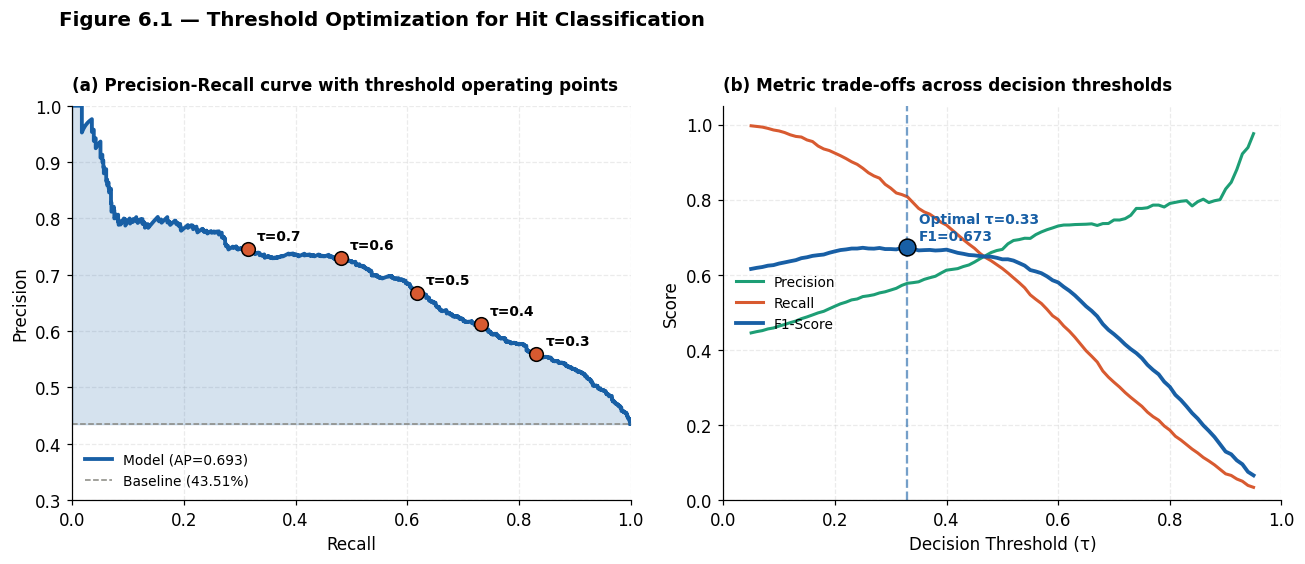

Saved fig_rq6_threshold_optimization.pdf / .png


In [5]:
# ===== Figure 6.1 — Two-panel threshold analysis =====
prec_curve, rec_curve, _ = precision_recall_curve(y_test, yprob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
from sklearn.metrics import average_precision_score
ap = average_precision_score(y_test, yprob)
ax.plot(rec_curve, prec_curve, linewidth=2.5, color=COLORS["primary"], label=f"Model (AP={ap:.3f})")
baseline = y_test.mean()
ax.axhline(baseline, color=COLORS["gray"], linestyle="--", linewidth=1, label=f"Baseline ({baseline:.2%})")
ax.fill_between(rec_curve, baseline, prec_curve, alpha=0.18, color=COLORS["primary"])
# Operating points
for _, row in threshold_df.iterrows():
    ax.scatter([row["Recall"]], [row["Precision"]], color=COLORS["accent"], s=80, zorder=5, edgecolor="black")
    ax.annotate(f"τ={row['Threshold']}", (row["Recall"], row["Precision"]),
                xytext=(6, 6), textcoords="offset points", fontsize=9, weight="bold")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_xlim(0, 1.0); ax.set_ylim(min(0.3, baseline-0.05), 1.0)
ax.legend(loc="lower left", fontsize=9)
ax.set_title("(a) Precision-Recall curve with threshold operating points", loc="left", pad=10, fontsize=11)
ax.grid(True, alpha=0.25, linestyle="--")
ax.set_axisbelow(True)

ax = axes[1]
ax.plot(thresholds, prec_arr, linewidth=2, color=COLORS["secondary"], label="Precision")
ax.plot(thresholds, rec_arr, linewidth=2, color=COLORS["accent"], label="Recall")
ax.plot(thresholds, f1_arr, linewidth=2.5, color=COLORS["primary"], label="F1-Score")
ax.axvline(optimal_t, color=COLORS["primary"], linestyle="--", alpha=0.6)
ax.scatter([optimal_t], [f1_arr[best_idx]], s=120, color=COLORS["primary"], zorder=5, edgecolor="black")
ax.text(optimal_t+0.02, f1_arr[best_idx]+0.02,
        f"Optimal τ={optimal_t:.2f}\nF1={f1_arr[best_idx]:.3f}",
        fontsize=9, weight="bold", color=COLORS["primary"])
ax.set_xlabel("Decision Threshold (τ)"); ax.set_ylabel("Score")
ax.set_xlim(0, 1.0); ax.set_ylim(0, 1.05)
ax.legend(loc="center left", fontsize=9)
ax.set_title("(b) Metric trade-offs across decision thresholds", loc="left", pad=10, fontsize=11)
ax.grid(True, alpha=0.25, linestyle="--")
ax.set_axisbelow(True)

fig.suptitle("Figure 6.1 — Threshold Optimization for Hit Classification", fontsize=13, fontweight="bold", x=0.05, ha="left", y=1.02)
plt.tight_layout()
plt.savefig("fig_rq6_threshold_optimization.pdf")
plt.savefig("fig_rq6_threshold_optimization.png")
plt.show()
print("Saved fig_rq6_threshold_optimization.pdf / .png")


## 6. Conclusion

The default 0.50 threshold is rarely optimal. Lowering the threshold favors recall (catch more hits, accept more false alarms); raising it favors precision (only flag confident bets). The choice should reflect business cost asymmetry.